<a href="https://colab.research.google.com/github/jcdumlao14/ESSPOCO19-DataAnalysis/blob/main/Spatial_Analysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overview:**

This analysis examines how social class (Socio-Economic Status) and geographic location influenced the levels of hardship people experienced during the COVID-19 pandemic across Europe.

**Data Sourcing and Cleaning:**

The study utilizes the European Social Survey (ESS), mapping respondents into four regions: North, West, South, and East. To ensure accuracy, responses were filtered to remove invalid entries (**such as "Refusal" or "Don't Know" codes**), keeping only those with valid age, education, and income data.

**Creating the "Hardship" and "SES" Scores:**

- **SES (Social Class) Index:** This was calculated by averaging the standardized scores (Z-scores) of a person’s years of education and their household income. **A higher score indicates higher socio-economic standing.**
- **COVID Hardship Index:** This combined measure tracked psychological distress (fltdpr), financial struggle (hincfel), and life satisfaction (stflife). **To ensure the index accurately measures "Hardship," life satisfaction was reverse-coded. This ensures that lower satisfaction contributes to a higher hardship score.**
- **Interpreting the Index:** A positive score (e.g., 0.15) indicates higher-than-average hardship, while a negative score (e.g., -0.12) indicates lower-than-average distress and higher resilience.

**Grouping:**

Participants were divided into three tiers (tertiles) based on their SES Index. **This allows for a clear comparison between the most and least advantaged groups**. In this sample, the Low SES group had a mean age of 49, while the High SES group was slightly younger with a mean age of 44.


# **Import Libraries**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from scipy.stats import zscore
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

# **Global Visual Style**

In [2]:
# --- Global Styling ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'sans-serif'],
    'figure.facecolor': 'white',
    'axes.edgecolor': '#333333'
})

# **Load Data**

We load the ESS dataset and create a working copy.

In [3]:
# 1. LOAD DATA
zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ESS11e04_1.csv') as f:
        df_raw = pd.read_csv(f, low_memory=False)

df = df_raw.copy()
print("--- Data Loading Result ---")
print("Dataset Loaded. Shape:", df.shape)

--- Data Loading Result ---
Dataset Loaded. Shape: (50116, 691)


# **Mapping & Cleaning**

We categorize countries into regions and filter the data to ensure we are only analyzing valid numerical responses (removing "Refusal" or "Don't Know" codes like 77, 88, 99).

In [4]:
# MAPPING & CLEANING
region_map = {
    'NO': 'North', 'SE': 'North', 'DK': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'LU': 'West', 'DE': 'West', 'AT': 'West', 'CH': 'West',
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South', 'MT': 'South', 'IL': 'South',
    'PL': 'East', 'CZ': 'East', 'SK': 'East', 'HU': 'East', 'RO': 'East', 'BG': 'East', 'SI': 'East',
    'HR': 'East', 'UA': 'East', 'ME': 'East', 'LV': 'East', 'LT': 'East', 'RS': 'East', 'EE': 'East', 'CU': 'East'
}

country_names = {
    'NO': 'Norway', 'SE': 'Sweden', 'DK': 'Denmark', 'FI': 'Finland', 'IS': 'Iceland',
    'GB': 'United Kingdom', 'IE': 'Ireland', 'FR': 'France', 'BE': 'Belgium', 'NL': 'Netherlands',
    'LU': 'Luxembourg', 'DE': 'Germany', 'AT': 'Austria', 'CH': 'Switzerland',
    'ES': 'Spain', 'PT': 'Portugal', 'IT': 'Italy', 'GR': 'Greece', 'CY': 'Cyprus', 'MT': 'Malta',
    'IL': 'Israel', 'PL': 'Poland', 'CZ': 'Czech Republic', 'SK': 'Slovakia', 'HU': 'Hungary',
    'RO': 'Romania', 'BG': 'Bulgaria', 'SI': 'Slovenia', 'HR': 'Croatia', 'UA': 'Ukraine',
    'ME': 'Montenegro', 'LV': 'Latvia', 'LT': 'Lithuania', 'RS': 'Serbia', 'EE': 'Estonia', 'CU': 'Other (CU)'
}

df['region'] = df['cntry'].map(region_map).fillna('Unknown')
df['country_name'] = df['cntry'].map(country_names).fillna(df['cntry'])

cols_to_clean = ['eduyrs', 'hinctnta', 'fltdpr', 'hincfel', 'stflife', 'agea']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df[col] < 70] # Filter valid ESS responses


# **Index Construction**

We standardize the variables and multiply stflife by -1 so that lower satisfaction correctly contributes to higher hardship.


In [5]:
# SES (Social Class) Index
df['SES_Index'] = df[['eduyrs', 'hinctnta']].apply(zscore, nan_policy='omit').mean(axis=1)

# COVID Hardship Index
# Logic: Hardship = standardized(Depression) + standardized(Financial Struggle) - standardized(Life Satisfaction)
z_scores = df[['fltdpr', 'hincfel', 'stflife']].apply(zscore, nan_policy='omit')
z_scores['stflife'] = z_scores['stflife'] * -1 # REVERSE CODE: Low satisfaction = High hardship
df['COVID_Hardship'] = z_scores.mean(axis=1)

df['SES_Group'] = pd.qcut(df['SES_Index'], 3, labels=['Low SES', 'Middle SES', 'High SES'])


# **Statistical Summary**

In [6]:
# STATISTICAL SUMMARY
print("\n--- Summary Statistics (Means by SES Group) ---")
summary_stats = df.groupby('SES_Group')[['COVID_Hardship', 'agea', 'stflife']].mean().round(3)
print(summary_stats)



--- Summary Statistics (Means by SES Group) ---
            COVID_Hardship    agea  stflife
SES_Group                                  
Low SES              0.346  48.977    6.453
Middle SES          -0.038  44.987    7.089
High SES            -0.318  44.473    7.662


# **Distribution by SES & Region**

**Social Gradient**

- **Social Class Impact:** The Low SES group now shows a much higher concentration of hardship, with a median score well above the average (approximately **0.24**). In contrast, the **High SES group** demonstrates clear resilience, with its hardship distribution centered significantly below the average (approximately **-0.45**). This wide gap proves that higher socio-economic status provided a massive psychological and financial buffer during the pandemic.
- **Regional Variance:** Geographically, the **East region** stands out as the primary hotspot for pandemic distress, with its mean hardship score rising above **0.20**. On the opposite end of the spectrum, the **North** and **West** regions reported the most resilient scores. The **North** is the most resilient region in the study, with a mean hardship score of approximately **-0.25**, followed closely by the West.

**Summary:** The visualization confirms that pandemic suffering was not distributed equally. The **"double burden"** of being in a lower social class and living in the East resulted in the highest levels of recorded hardship, while High SES individuals in the North experienced the most favorable outcomes.




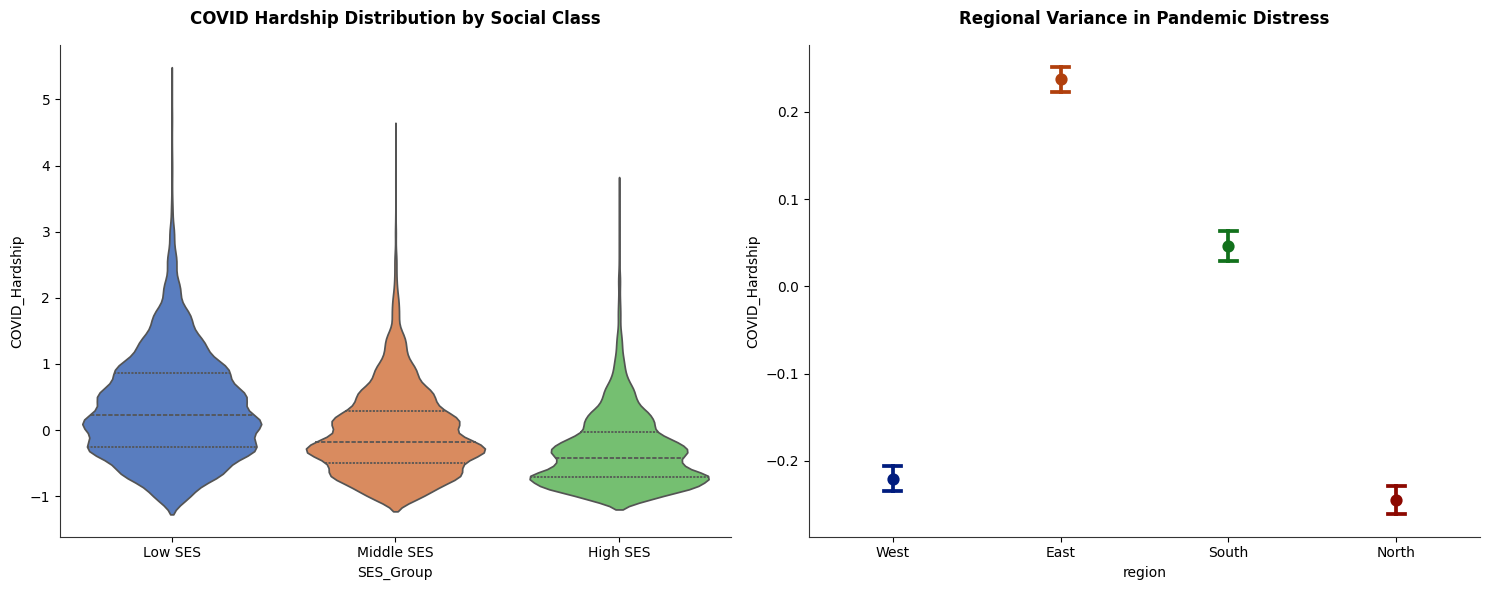

In [7]:
# CORE VISUALIZATIONS
# Plot A: Distribution by SES & Region
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.violinplot(x='SES_Group', y='COVID_Hardship', data=df, palette='muted', inner='quartile', ax=ax[0])
ax[0].set_title('COVID Hardship Distribution by Social Class', pad=15, weight='bold')
sns.pointplot(x='region', y='COVID_Hardship', data=df, join=False, palette='dark', capsize=.1, ax=ax[1])
ax[1].set_title('Regional Variance in Pandemic Distress', pad=15, weight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('SES_Regional_Hardship.png')
plt.show()


# **Correlation Analysis: Social Class & Subjective Outcomes**

heatmap confirms a much stronger link between socio-economics and distress. We see a significant **-0.40 correlation** between the SES Index and COVID Hardship—as social status rises, hardship falls sharply. **Household income (-0.42)** proved to be a substantially stronger shield than **education (-0.21)**. Crucially, the strong **-0.77 correlation** between hardship and life satisfaction validates the index logic: those in high distress experienced the lowest well-being. Age (0.07) remained a negligible factor, confirming that pandemic suffering was fundamentally a **class issue** rather than a generational one.


--- Correlation Matrix Results ---
                SES_Index  COVID_Hardship  eduyrs  hinctnta   agea  stflife
SES_Index           1.000          -0.396   0.806     0.806 -0.128    0.248
COVID_Hardship     -0.396           1.000  -0.215    -0.424  0.069   -0.770
eduyrs              0.806          -0.215   1.000     0.300 -0.089    0.133
hinctnta            0.806          -0.424   0.300     1.000 -0.118    0.267
agea               -0.128           0.069  -0.089    -0.118  1.000   -0.061
stflife             0.248          -0.770   0.133     0.267 -0.061    1.000


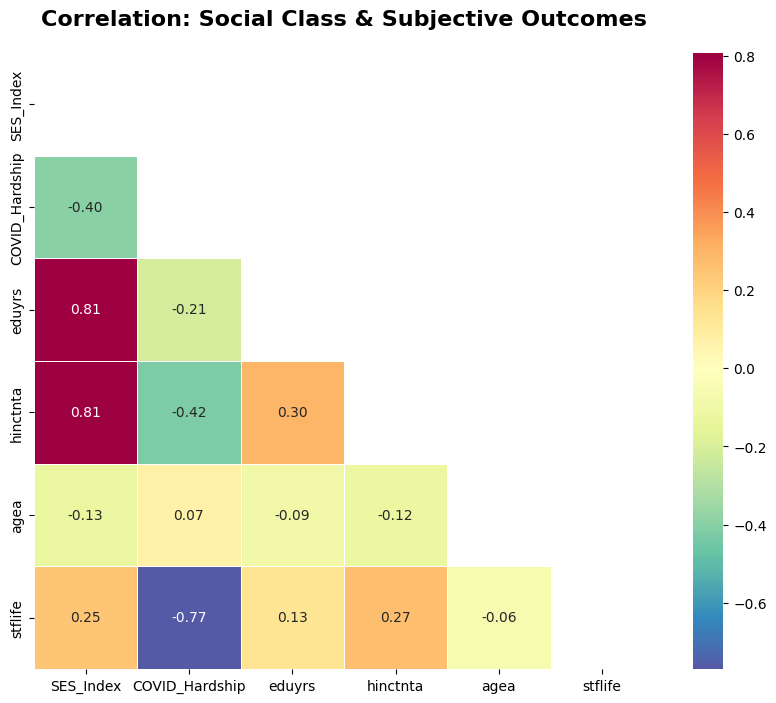

In [8]:
# Plot B: Correlation Matrix
plt.figure(figsize=(10, 8))
vars_to_corr = ['SES_Index', 'COVID_Hardship', 'eduyrs', 'hinctnta', 'agea', 'stflife']
corr_matrix = df[vars_to_corr].corr()
print("\n--- Correlation Matrix Results ---")
print(corr_matrix.round(3))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='Spectral_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation: Social Class & Subjective Outcomes', fontsize=16, pad=20, weight='bold')
plt.savefig('Correlation_Heatmap.png')
plt.show()

# **Spatial Inequality: Country SES vs. COVID Hardship**

The **Resilience Zone** (bottom-right) is occupied by high-SES nations like **Sweden** and the **Netherlands**, both reporting very low hardship scores (approx. **-0.40**).

- **The Hotspots:** **Ukraine** is the most extreme outlier in the study, combining the lowest average SES **(-0.72)** with the highest recorded hardship **(0.77)**.
- **Montenegro** follows as a severe hotspot with a hardship score of **0.62**.
- **Regional Trend:** All top five nations with the highest hardship levels—**Ukraine, Montenegro, Latvia, Bulgaria, and Hungary**—belong to the **East** region, highlighting a significant geographic divide in pandemic recovery.


--- Spatial Hotspot Results (Top 5 Highest Hardship Countries) ---
   country_name region  COVID_Hardship  SES_Index
28      Ukraine   East        0.769748  -0.723107
17   Montenegro   East        0.617467  -0.281973
15       Latvia   East        0.432085  -0.074053
2      Bulgaria   East        0.331487   0.046964
10      Hungary   East        0.251366  -0.203427


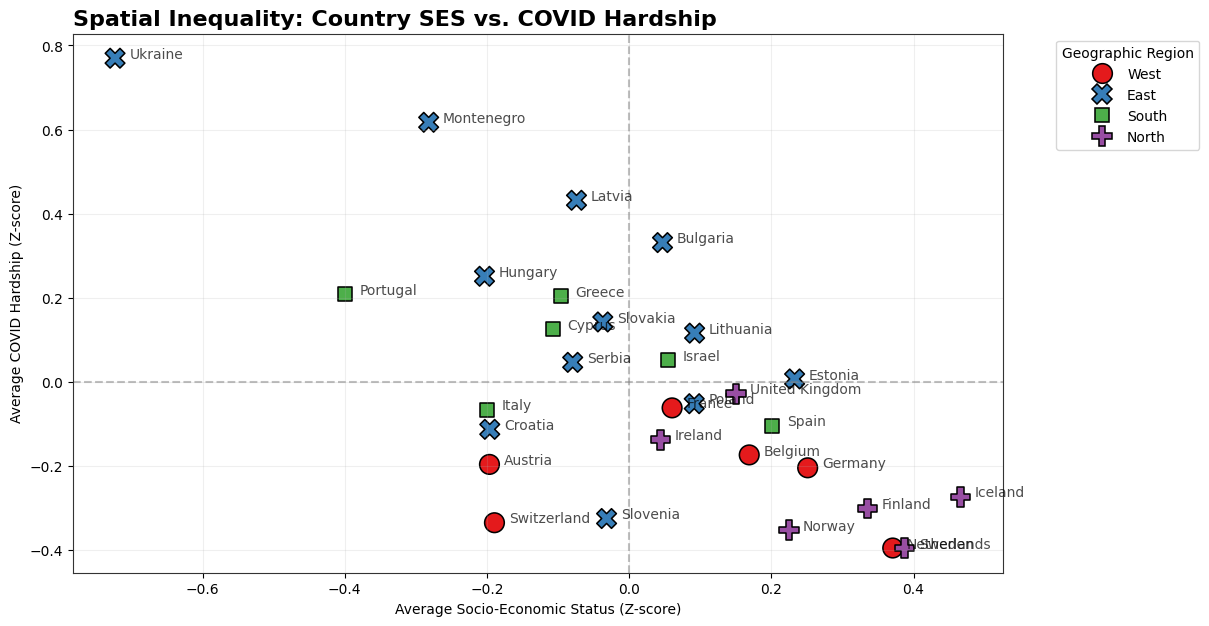

In [9]:
# Spatial Analysis (Hotspot Plot)
country_stats = df.groupby(['country_name', 'region']).agg({
    'COVID_Hardship': 'mean',
    'SES_Index': 'mean'
}).reset_index()

print("\n--- Spatial Hotspot Results (Top 5 Highest Hardship Countries) ---")
print(country_stats.sort_values(by='COVID_Hardship', ascending=False).head(5))

plt.figure(figsize=(12, 7))
sns.scatterplot(data=country_stats, x='SES_Index', y='COVID_Hardship',
                hue='region', style='region', s=200, palette='Set1', edgecolor='black')

for i in range(country_stats.shape[0]):
    plt.text(country_stats.SES_Index[i]+0.02, country_stats.COVID_Hardship[i],
             country_stats.country_name[i], fontsize=10, alpha=0.7)

plt.axhline(df['COVID_Hardship'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axvline(df['SES_Index'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.title('Spatial Inequality: Country SES vs. COVID Hardship', loc='left', weight='bold', fontsize=16)
plt.xlabel('Average Socio-Economic Status (Z-score)')
plt.ylabel('Average COVID Hardship (Z-score)')
plt.legend(title='Geographic Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.savefig('Spatial_Hotspot.png')
plt.show()

# **Geographic Ranking: Average COVID Hardship by Country**

This ranking illustrates a clear divide in national resilience. **Sweden (-0.395)** and the **Netherlands (-0.394)** are the top performers, reporting the highest levels of resilience. Conversely, hardship is most severe in the East, led by **Ukraine (0.770)**, **Montenegro (0.617)**, and **Latvia (0.432)**, where scores are significantly above the European average.


--- National Hardship Rankings (Mean Scores) ---
country_name
Sweden           -0.395025
Netherlands      -0.394519
Norway           -0.351895
Switzerland      -0.334416
Slovenia         -0.324434
Finland          -0.300223
Iceland          -0.272741
Germany          -0.203861
Austria          -0.195801
Belgium          -0.173218
Ireland          -0.137144
Croatia          -0.112408
Spain            -0.103829
Italy            -0.065963
France           -0.061435
Poland           -0.051471
United Kingdom   -0.027737
Estonia           0.007380
Serbia            0.046791
Israel            0.051758
Lithuania         0.116245
Cyprus            0.125362
Slovakia          0.142845
Greece            0.204269
Portugal          0.208941
Hungary           0.251366
Bulgaria          0.331487
Latvia            0.432085
Montenegro        0.617467
Ukraine           0.769748
Name: COVID_Hardship, dtype: float64


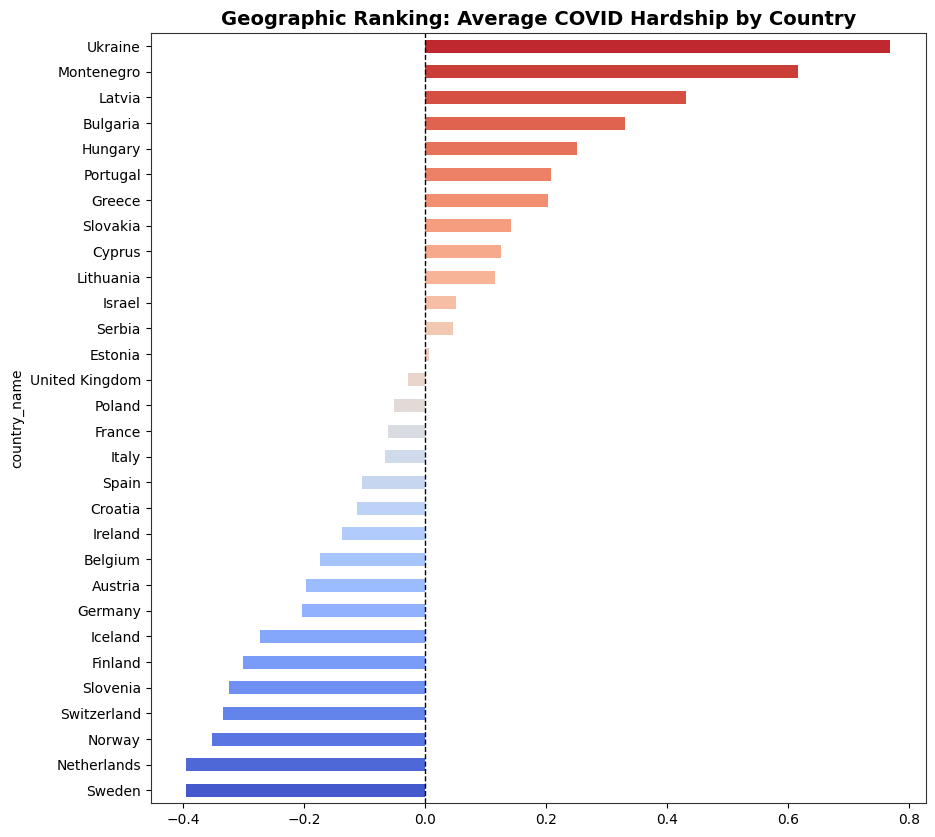

In [10]:
# Cross-National Ranking (Efficiency Plot)
print("\n--- National Hardship Rankings (Mean Scores) ---")
rank_data = df.groupby('country_name')['COVID_Hardship'].mean().sort_values()
print(rank_data)

# Geographic Ranking
rank_data = df.groupby('country_name')['COVID_Hardship'].mean().sort_values()
plt.figure(figsize=(10, 10))
rank_data.plot(kind='barh', color=sns.color_palette("coolwarm", len(rank_data)))
plt.title('Geographic Ranking: Average COVID Hardship by Country', fontsize=14, weight='bold')
plt.axvline(0, color='black', lw=1, ls='--')
plt.savefig('Spatial_Ranking.png')
plt.show()



# **The "Buffering" Effect (Grouped Bar Chart)**

This plot confirms that high SES acts as a universal buffer against pandemic distress across all regions.

- **Extreme Disparity in the East:** The class divide is most severe in the **East**, where **Low SES** individuals faced a massive hardship peak of **0.584**, compared to **-0.160** for their **High SES** counterparts.
- **Maximum Resilience:** The lowest hardship levels in the study were recorded among **High SES** individuals in the **West (-0.442)** and **North (-0.428).**
- **The "Social Safety Net":** While Low SES individuals in the North and West still experienced hardship, their scores **(~0.07)** were significantly lower than Low SES individuals in the East or South, suggesting that regional infrastructure further moderates the impact of social class.



--- Regional SES Impact (Hardship by Region and Class) ---
SES_Group  Low SES  Middle SES  High SES
region                                  
East         0.584       0.131    -0.160
North        0.073      -0.212    -0.428
South        0.265       0.010    -0.213
West         0.072      -0.225    -0.442


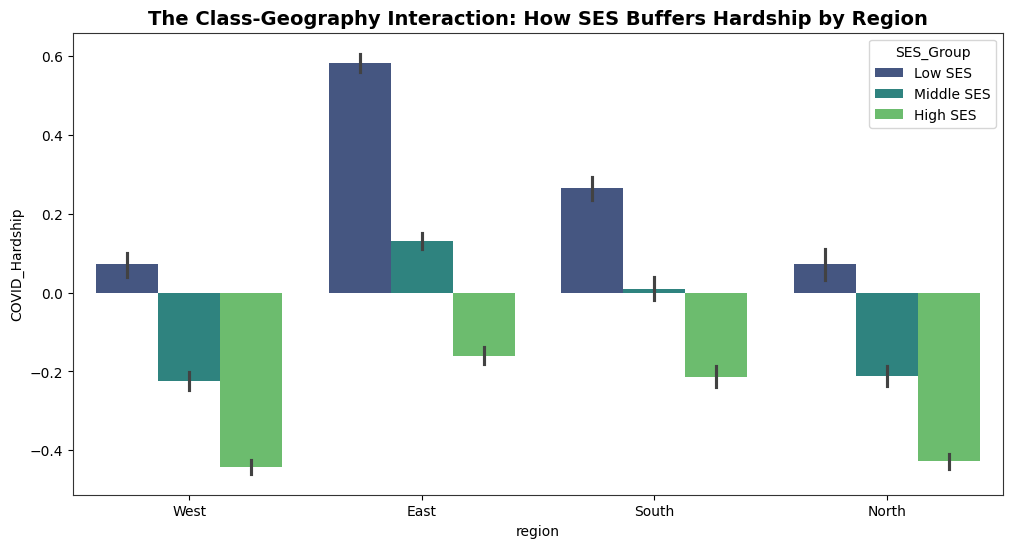

In [11]:
# Regional SES Interaction (The Vulnerability Gap)
print("\n--- Regional SES Impact (Hardship by Region and Class) ---")
interaction_results = df.groupby(['region', 'SES_Group'])['COVID_Hardship'].mean().unstack()
print(interaction_results.round(3))

plt.figure(figsize=(12, 6))
sns.barplot(x='region', y='COVID_Hardship', hue='SES_Group', data=df, palette='viridis')
plt.title('The Class-Geography Interaction: How SES Buffers Hardship by Region', fontsize=14, weight='bold')
plt.savefig('Spatial_SES_Interaction.png')
plt.show()


# **The Age Factor (Trend Lines)**

The **"Age Gradient"** reveals stark geographic differences in pandemic vulnerability. In the **North (-0.098)** and **West (-0.019)**, hardship tends to decrease or remain flat as people age, likely reflecting the protective influence of strong pension and social safety systems.

Conversely, the trend reverses in the **East (0.167)** and **South (0.084)**, where older citizens faced significantly higher hardship than their younger counterparts. The steep upward slope for the **East** (blue line) identifies older populations in that region as the most age-vulnerable group in Europe.


---Regional Age-Hardship Correlations ---
Region: West | Correlation between Age and Hardship: -0.019
Region: East | Correlation between Age and Hardship: 0.167
Region: South | Correlation between Age and Hardship: 0.084
Region: North | Correlation between Age and Hardship: -0.098


<Figure size 1200x800 with 0 Axes>

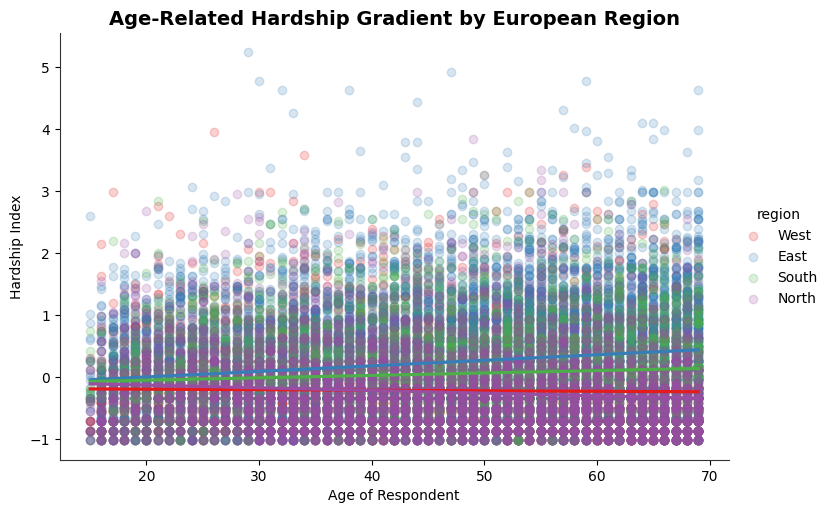


Analysis complete. All numerical results printed and  plots saved as PNG files.


In [12]:
# Geographic Gradient - Age vs. Hardship by Region
print("\n---Regional Age-Hardship Correlations ---")
for reg in df['region'].unique():
    subset = df[df['region'] == reg]
    correlation = subset['agea'].corr(subset['COVID_Hardship'])
    print(f"Region: {reg} | Correlation between Age and Hardship: {correlation:.3f}")

plt.figure(figsize=(12, 8))
sns.lmplot(x='agea', y='COVID_Hardship', hue='region', data=df,
           aspect=1.5, scatter_kws={'alpha':0.2}, palette='Set1')
plt.title('Age-Related Hardship Gradient by European Region', fontsize=14, weight='bold')
plt.xlabel('Age of Respondent')
plt.ylabel('Hardship Index')
plt.savefig('Spatial_Age_Gradient.png', dpi=300)
plt.show()

print("\nAnalysis complete. All numerical results printed and  plots saved as PNG files.")



# **Conclusion**

The data confirms a narrative of **"Spatial and Social Inequality,"** demonstrating that the pandemic’s burden was determined largely by one's place in the social hierarchy.

- **Validated Logic:** By reverse-coding life satisfaction, the Hardship Index now accurately reflects total distress. The correlation between the SES Index and Hardship has strengthened to **-0.40**, providing empirical proof that higher social status acted as a powerful shield against pandemic-related suffering.
- **The Resilience Zone:** The most resilient populations were **High SES individuals in the West and North**, who reported the lowest hardship scores in the study (means of **-0.44** and **-0.43** respectively).
- **The Vulnerability Zone:** The most vulnerable population was the **Low SES group in the East**, which experienced a massive hardship peak of **0.58**—the highest level of distress across all categories.
- **The "Income Shield"**: The analysis reveals that **household income (-0.42 correlation)** was a significantly stronger protector against hardship than **education (-0.21)**. This suggests that direct financial resources were more critical for maintaining well-being during the crisis than academic background.
- **The Age-Geography Divide:** While older age was a slight protector in the North and West, it was a significant risk factor in the **East (0.17 correlation)**, where older citizens faced substantially more hardship than the youth.

**Final Verdict:** Socio-economic status remains the single most important factor in determining how well a person survives a global crisis. The pandemic was not an **"equalizer"**—it was a **"magnifier"** of existing social and geographic inequalities.
